--- Simple Linear Regression ---
Mean Squared Error (MSE): 86.8536206809736
R-squared (R2): 0.5482254051576954


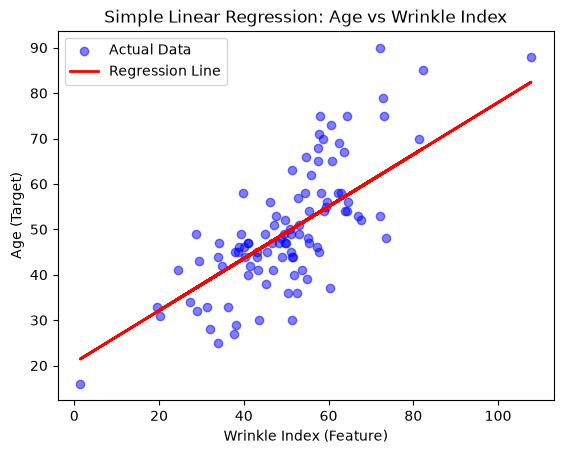

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. โหลดข้อมูลจากไฟล์ CSV
df = pd.read_csv('lab1_age_prediction_data.csv')

# เลือก Feature (X) ตัวเดียว และ Target (y)
X_simple = df[['wrinkle_index']]
y = df['age']

# 2. แบ่งข้อมูลสำหรับ Training (80%) และ Testing (20%)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# 3. สร้างและฝึกสอน (Training) แบบจำลอง Simple Linear Regression
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

# 4. ทำนายผลกับชุดข้อมูลทดสอบ
y_pred_s = model_simple.predict(X_test_s)

# 5. ประเมินผล
print("--- Simple Linear Regression ---")
print("Mean Squared Error (MSE):", mean_squared_error(y_test_s, y_pred_s))
print("R-squared (R2):", r2_score(y_test_s, y_pred_s))

# 6. วาดกราฟเส้นแนวโน้ม (Decision Boundary/Regression Line)
plt.scatter(X_test_s, y_test_s, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Wrinkle Index (Feature)')
plt.ylabel('Age (Target)')
plt.title('Simple Linear Regression: Age vs Wrinkle Index')
plt.legend()
plt.show()

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. โหลดข้อมูลจากไฟล์ CSV ที่สร้างไว้
df = pd.read_csv('lab1_age_prediction_data.csv')

# 2. กำหนดตัวแปรต้น (Features) หลายตัว และตัวแปรตาม (Target)
X_multi = df[['wrinkle_index', 'skin_elasticity', 'hair_grayness']]
y = df['age']

# 3. แบ่งชุดข้อมูลสำหรับ Train (80%) และ Test (20%)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# 4. สร้างและฝึกสอนแบบจำลอง Multiple Linear Regression
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# 5. นำโมเดลไปทำนายผลกับชุดข้อมูล Test
y_pred_m = model_multi.predict(X_test_m)

# ---------------------------------------------------------
# ส่วนของการแสดงผลเป็นตาราง (ใช้ Pandas DataFrame)
# ---------------------------------------------------------

# ตารางที่ 1: ตารางค่าน้ำหนักของคุณลักษณะ (Feature Coefficients)
coef_df = pd.DataFrame(model_multi.coef_, X_multi.columns, columns=['Coefficient'])
print("=== 1. ตารางค่าน้ำหนัก (Feature Coefficients) ===")
print(coef_df)
print("\n" + "="*50 + "\n")

# ตารางที่ 2: ตารางเปรียบเทียบผลการทำนาย (Age Prediction Results)
# นำค่าจริง (y_test_m) และค่าที่ทำนายได้ (y_pred_m) มาสร้างเป็นตาราง และปัดเศษทศนิยม
prediction_results = pd.DataFrame({
    'Actual Age (อายุจริง)': y_test_m.values, 
    'Predicted Age (อายุที่ทำนาย)': np.round(y_pred_m).astype(int)
})

print("=== 2. ตารางเปรียบเทียบผลการทำนาย (แสดง 10 ข้อมูลแรก) ===")
print(prediction_results.head(10))

=== 1. ตารางค่าน้ำหนัก (Feature Coefficients) ===
                 Coefficient
wrinkle_index       0.621018
skin_elasticity    -0.310487
hair_grayness       0.392856


=== 2. ตารางเปรียบเทียบผลการทำนาย (แสดง 10 ข้อมูลแรก) ===
   Actual Age (อายุจริง)  Predicted Age (อายุที่ทำนาย)
0                     75                            72
1                     48                            54
2                     85                            80
3                     49                            50
4                     53                            55
5                     52                            53
6                     57                            58
7                     70                            62
8                     47                            54
9                     44                            51


In [2]:
# 1. เลือก Features หลายตัว
X_multi = df[['wrinkle_index', 'skin_elasticity', 'hair_grayness']]
y = df['age']

# 2. แบ่งข้อมูล Training และ Testing
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# 3. สร้างและฝึกสอนแบบจำลอง Multiple Linear Regression
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# 4. ทำนายผล
y_pred_m = model_multi.predict(X_test_m)

# 5. ประเมินผลเปรียบเทียบ
print("--- Multiple Linear Regression ---")
print("Mean Squared Error (MSE):", mean_squared_error(y_test_m, y_pred_m))
print("R-squared (R2):", r2_score(y_test_m, y_pred_m))

# แสดงค่าน้ำหนัก (Coefficients) ของแต่ละ Feature
coef_df = pd.DataFrame(model_multi.coef_, X_multi.columns, columns=['Coefficient'])
print("\nFeature Coefficients:")
print(coef_df)

--- Multiple Linear Regression ---
Mean Squared Error (MSE): 16.775878271398778
R-squared (R2): 0.912739209375928

Feature Coefficients:
                 Coefficient
wrinkle_index       0.621018
skin_elasticity    -0.310487
hair_grayness       0.392856


In [3]:
# แสดงตารางเปรียบเทียบระหว่าง อายุจริง (Actual Age) และ อายุที่ทำนายได้ (Predicted Age) 10 อันดับแรก
prediction_results = pd.DataFrame({
    'Actual Age': y_test_m.values, 
    'Predicted Age': np.round(y_pred_m).astype(int)
})
print("--- Age Prediction Results (Test Set Sample) ---")
print(prediction_results.head(10))

# ---------------------------------------------------------
# จำลองสถานการณ์: มีภาพใบหน้าใหม่เข้ามา และสกัดค่า Features ได้ดังนี้
# wrinkle_index = 65 (ริ้วรอยเยอะ), skin_elasticity = 35 (ความยืดหยุ่นน้อย), hair_grayness = 70 (ผมหงอกมาก)
new_face_features = pd.DataFrame([[65, 35, 70]], columns=['wrinkle_index', 'skin_elasticity', 'hair_grayness'])

# ให้โมเดลทำนายอายุจากใบหน้านี้
predicted_age = model_multi.predict(new_face_features)

print("\n--- New Data Prediction ---")
print(f"ผลการทำนายอายุจากใบหน้าใหม่ (ข้อมูลสมมติ): ประมาณ {int(predicted_age[0])} ปี")

--- Age Prediction Results (Test Set Sample) ---
   Actual Age  Predicted Age
0          75             72
1          48             54
2          85             80
3          49             50
4          53             55
5          52             53
6          57             58
7          70             62
8          47             54
9          44             51

--- New Data Prediction ---
ผลการทำนายอายุจากใบหน้าใหม่ (ข้อมูลสมมติ): ประมาณ 81 ปี
